Example of how to parse the files and load data in dataframes.

In [41]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import math
matplotlib.use('TkAgg')
%matplotlib notebook
%matplotlib inline


In [42]:
data_path = os.getcwd() + os.sep + 'data'
print(data_path)

/Users/filipnordqvist/Documents/GitHub/Examensarbete/data


In [43]:
# Loading data functions
def loader(data_path, blacklist):
    data = []
    all_data_csv = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
    for name in os.listdir(data_path):
        if name != '.DS_Store' and 'csv' not in name and 'txt' not in name:
            print('---------------------------------------------')
            print("Loading walking data for subject: ",name)
            new_path = data_path + os.sep + name
            for name_in in os.listdir(new_path):
                if name_in != '.DS_Store' and name_in not in blacklist:
                    print("Loading test: ", name_in)
                    motion_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'motion.csv')
                    position_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'positions.csv')
                    orientation_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'orientation.csv')
                    steps_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'steps.csv')
                    event_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'events.csv')

                    anon_test = walking_test(
                        name_in, event_csv,
                        motion_csv,
                        orientation_csv,
                        position_csv,
                        steps_csv
                    )
                    data.append(anon_test)

    return data, all_data_csv

class walking_test:
    def __init__(self, filename, events, motion, orientation, positions, steps): #
        self.filename = filename
        self.events = events
        self.motion = motion
        self.orientation = orientation
        self.positions = positions
        self.steps = steps

In [44]:
# Uploading metadata and determining blacklist
metadata = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
print("Metadata columns: ", metadata.columns)

noIMU = metadata[metadata['hasMotion'] == False]['testName'].tolist()
noGPS = metadata[metadata['hasGNSS'] == False]['testName'].tolist()
blacklist = noIMU + noGPS
print("Blacklist: ", blacklist)

Metadata columns:  Index(['subject', 'testID', 'testName', 'isPatient', 'distanceReference',
       'hasMotion', 'hasGNSS', 'device', 'distanceByApp', 'totSteps',
       'path curvature', 'total_gaps_time_inertial', 'total_gaps_time_gnss',
       'gt_type', 'country', 'gnss_anonimized', 'duration [s]', 'fs_acc',
       'fs_gnss', 'fs_steps', 'average_walking_speed', 'smartphone_position',
       'smartphone app'],
      dtype='object')
Blacklist:  ['0_0', '0_1', '0_2', '0_3', '0_4', '0_5', '0_6', '0_7', '0_8', '0_9', '0_10', '0_11', '0_12', '0_13', '0_14', '1_0', '1_1', '1_2', '1_3', '1_4', '1_5', '1_6', '1_7', '1_8', '1_9', '2_0', '2_1', '2_2', '2_3', '2_4', '2_5', '2_6', '2_7', '2_8', '2_9', '3_0', '3_5', '3_6', '3_7', '3_8', '3_9', '9_0', '9_1', '9_2', '9_3', '9_4', '9_5', '9_6', '9_7', '9_8', '9_9', '9_10', '15_0', '15_1', '15_2', '15_3', '15_4']


In [45]:
# Loading data
selection, info_all_tests = loader(data_path, blacklist=blacklist)
print("Successfully loaded data")

---------------------------------------------
Loading walking data for subject:  subject_12
Loading test:  12_5
Loading test:  12_2
Loading test:  12_3
Loading test:  12_4
Loading test:  12_10
Loading test:  12_11
Loading test:  12_1
Loading test:  12_6
Loading test:  12_8
Loading test:  12_9
Loading test:  12_7
Loading test:  12_0
Loading test:  12_13
Loading test:  12_12
---------------------------------------------
Loading walking data for subject:  subject_15
---------------------------------------------
Loading walking data for subject:  subject_14
Loading test:  14_9
Loading test:  14_0
Loading test:  14_7
Loading test:  14_6
Loading test:  14_1
Loading test:  14_8
Loading test:  14_14
Loading test:  14_13
Loading test:  14_12
Loading test:  14_4
Loading test:  14_3
Loading test:  14_2
Loading test:  14_5
Loading test:  14_10
Loading test:  14_11
---------------------------------------------
Loading walking data for subject:  subject_13
Loading test:  13_11
Loading test:  13_10
L

In [46]:
# Example of what a walking test contains:
print("Selection[0] contains: ")
print("Filename: ", selection[0].filename)
#Events
print("Events: ", selection[0].events.head())
#Motion
print("Motion: ", selection[0].motion.head())
#Orientation
print("Orientation: ", selection[0].orientation.head())
#Positions
print("Positions: ", selection[0].positions.head())
#Steps
print("Steps: ", selection[0].steps.head())

Selection[0] contains: 
Filename:  12_5
Events:     Unnamed: 0  signalStart  testStart        testEnd
0           0            0      961.0  241776.000023
Motion:     Unnamed: 0     ms    accelX    accelY    accelZ  accelWithGX  accelWithGY  \
0           0  301.0  0.438315 -0.063984 -0.070899    -0.022308     1.661179   
1           1  326.0  0.498090 -0.201496  0.016141    -0.035461     1.648026   
2           2  344.0  0.458053 -0.219058 -0.166888    -0.171860     1.747330   
3           3  366.0  0.212662 -0.051397 -0.305197    -0.256805     1.845428   
4           4  383.0  0.212662 -0.051397 -0.305197    -0.429092     1.931564   

   accelWithGZ  rotRateAlpha  rotRateBeta  rotRateGamma  interval  
0     9.639145      2.197900     3.448972      7.877995        16  
1     9.442932      5.656489     1.173263      5.241214        16  
2     9.349625      6.130341     0.611111      3.747971        16  
3     9.267059      7.771335     2.842233      4.861783        16  
4     9.143829 

In [47]:
#Saras code
def crowDist(point1, point2):
    lat1 = point1.latitude
    lat2 = point2.latitude
    lon1 = point1.longitude
    lon2 = point2.longitude
    R = 6371  # km
    dLat = math.radians(lat2 - lat1)
    dLon = math.radians(lon2 - lon1)
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)
    a = math.sin(dLat / 2) * math.sin(dLat / 2) + \
        math.sin(dLon / 2) * math.sin(dLon / 2) * math.cos(lat1) * math.cos(lat2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = R * c
    return d * 1000

Total distance traveled for 3_4: 614.26 meters
   time_s  distance_m  delta_time_s  speed_mps
0   0.000    0.000000           NaN        NaN
1   2.270   14.722436         2.270   6.485655
2   3.271    5.950942         1.001   5.944997
3   4.271    7.219821         1.000   7.219821
4   5.259    5.592460         0.988   5.660385
5   6.254    3.223548         0.995   3.239747
6   7.250    2.222455         0.996   2.231380
7   8.257    1.278514         1.007   1.269626
8   9.258    0.508253         1.001   0.507745
9  10.249    0.453999         0.991   0.458122


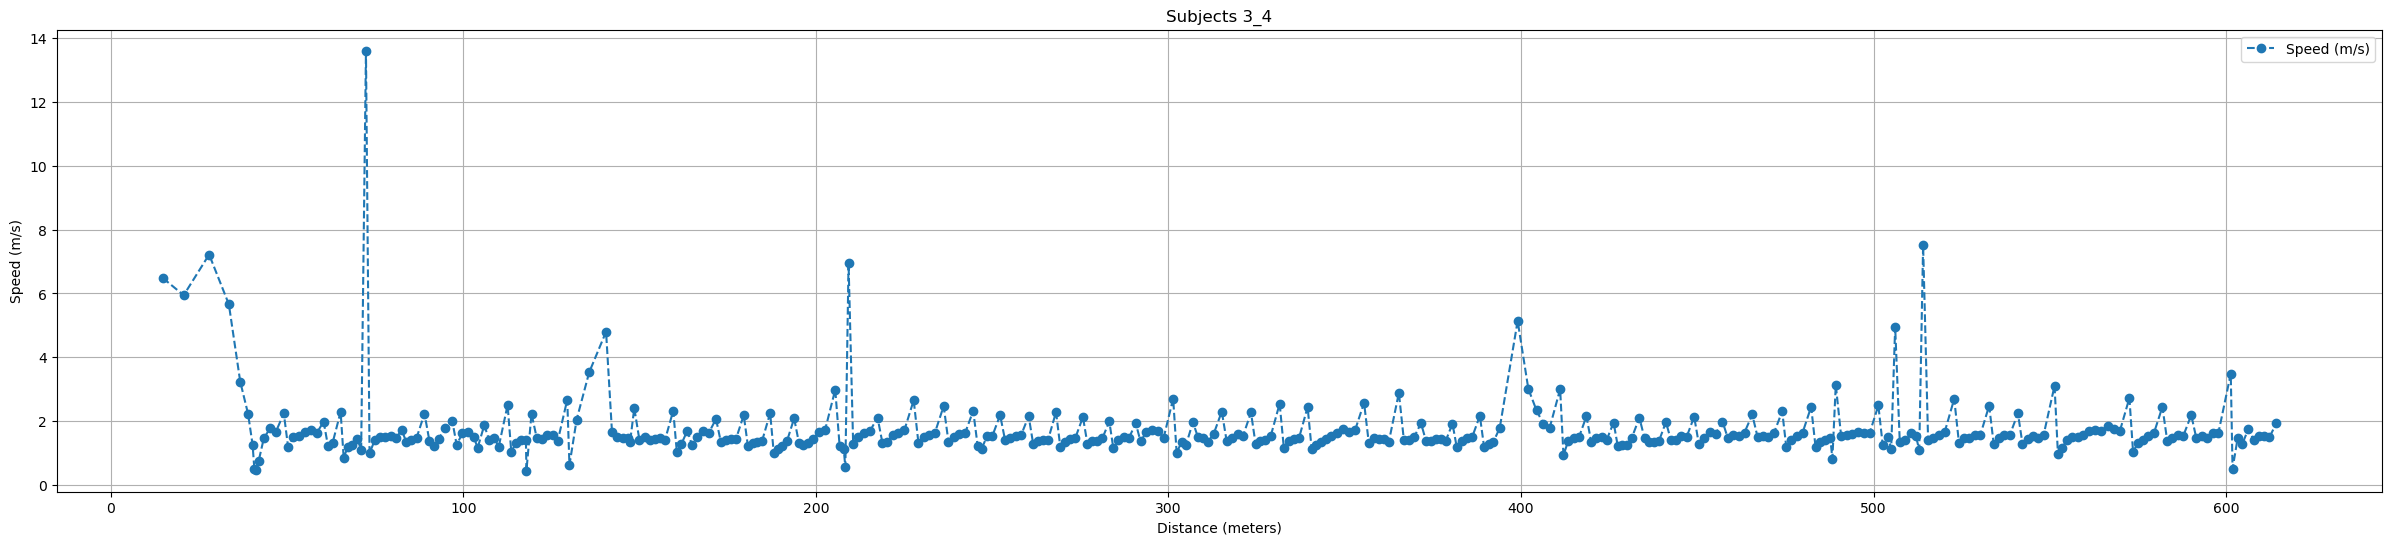

In [60]:
import math

# Function to filter tests by subject name
def filter_tests_by_subject(selection, subject_name):
    return [test for test in selection if test.filename.startswith(subject_name)]

# Example usage of subject 12
subject_name = '3_4'  # Replace with the desired subject name
filtered_selection = filter_tests_by_subject(selection, subject_name)

# Proceed with the filtered selection
for test in filtered_selection:
    positions_data = test.positions.copy()  # Important to copy the data to avoid modifying the original

    # Convert time to seconds from start
    positions_data['time_s'] = (positions_data['ms'] - positions_data['ms'].min()) / 1000

    # Calculate distance between points (protects against index errors)
    distances = [0] + [
        crowDist(positions_data.iloc[i-1], positions_data.iloc[i])
        for i in range(1, len(positions_data))
    ]
    positions_data['distance_m'] = distances

    # Total distance
    total_distance = positions_data['distance_m'].sum()
    print(f"Total distance traveled for {test.filename}: {total_distance:.2f} meters")

    # Calculate time difference between measurement points
    positions_data['delta_time_s'] = positions_data['time_s'].diff()

    # Protect against division by small values or zero
    min_time_threshold = 0.1  # Minimum allowed time difference in seconds
    positions_data['delta_time_s'] = positions_data['delta_time_s'].clip(lower=min_time_threshold)

    # Calculate speed in m/s
    positions_data['speed_mps'] = positions_data['distance_m'] / positions_data['delta_time_s']

    #Show the first 10 rows of data
    print(positions_data[['time_s', 'distance_m', 'delta_time_s', 'speed_mps']].head(10))

    # Plot for speed vs distance
    plt.figure(figsize=(30, 6))
    plt.plot(positions_data['distance_m'].cumsum(), positions_data['speed_mps'], marker='o', linestyle='--', label='Speed (m/s)')
    plt.xlabel('Distance (meters)')
    plt.ylabel('Speed (m/s)')
    plt.title(f"Subjects {test.filename}")
    plt.legend()
    plt.grid()
    plt.show()


    latitude  longitude    altitude  speed_mps
1  51.751875  -1.257630  126.900002   6.485655
2  51.751855  -1.257550  126.900002   5.944997
3  51.751919  -1.257533  126.900002   7.219821
4  51.751968  -1.257551  126.900002   5.660385
5  51.751994  -1.257572  126.900002   3.239747
Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1161
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0342
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0180
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0166
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0171
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0134
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0143
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0110
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0140
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0135
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0132
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0080
Epoch 13/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0098
Epoch 14/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0088
Epoch 15/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0076
Epoch 16/50
12/12 ━━━━━━━━━━━

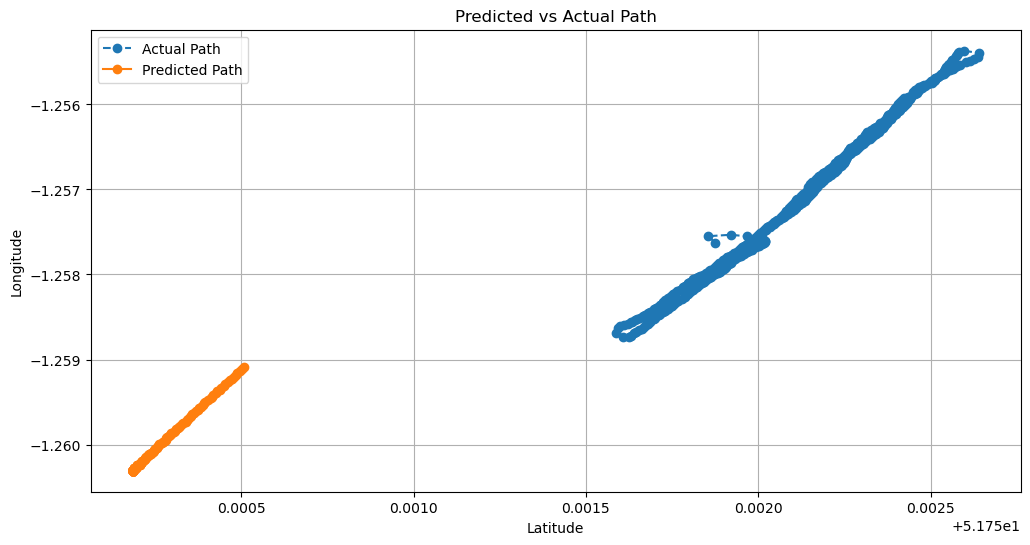

In [ ]:
#Code from GeekforGeeks GRU
# Importing Libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam

positions_data = positions_data[['latitude', 'longitude', 'altitude', 'speed_mps']].dropna()

#Checking if the data is loaded correctly
print(positions_data.head())

# Scaling the data using the same feature range as the example
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(positions_data[['latitude', 'longitude', 'altitude', 'speed_mps']].values)

if np.isnan(scaled_data).any():
    print("Datan innehåller NaN efter skalning!")

#Preparing the data for GRU
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        a = data[i:(i + time_step), :]
        X.append(a)
        y.append(data[i + time_step, :])  # Hela nästa datapunkt
    return np.array(X), np.array(y)
time_step = 10  # Number of previous time steps to consider
X, y = create_dataset(scaled_data, time_step)
# Reshaping the data to be suitable for GRU input
X = X.reshape(X.shape[0], X.shape[1], X.shape[2])

#Building the GRU model
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(GRU(units=50))
model.add(Dense(units=4)) 
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

#Training the model
model.fit(X, y, epochs=50, batch_size=32)

# Making predictions
input_sequence = scaled_data[-time_step:].reshape(1, time_step, scaled_data.shape[1])
predicted_values = model.predict(input_sequence)  # Shape: (1, 4)

# Invertera hela raden (alla features)
inverted_prediction = scaler.inverse_transform(predicted_values)[0]

print("Nästa predicerade punkt:")
print(f"Latitude:  {inverted_prediction[0]}")
print(f"Longitude: {inverted_prediction[1]}")
print(f"Altitude:  {inverted_prediction[2]}")
print(f"Speed:     {inverted_prediction[3]} m/s")


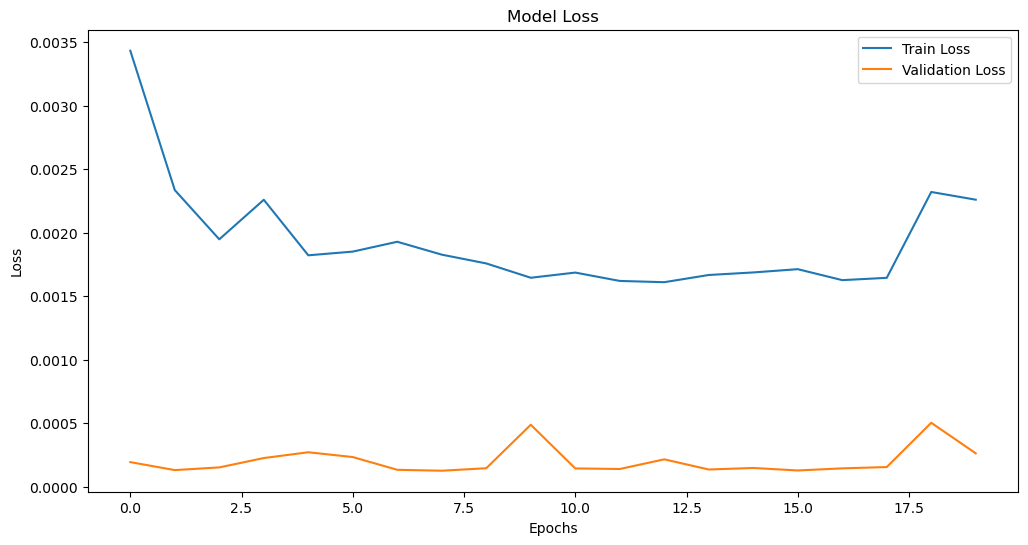

In [62]:
# Visualize the training process
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



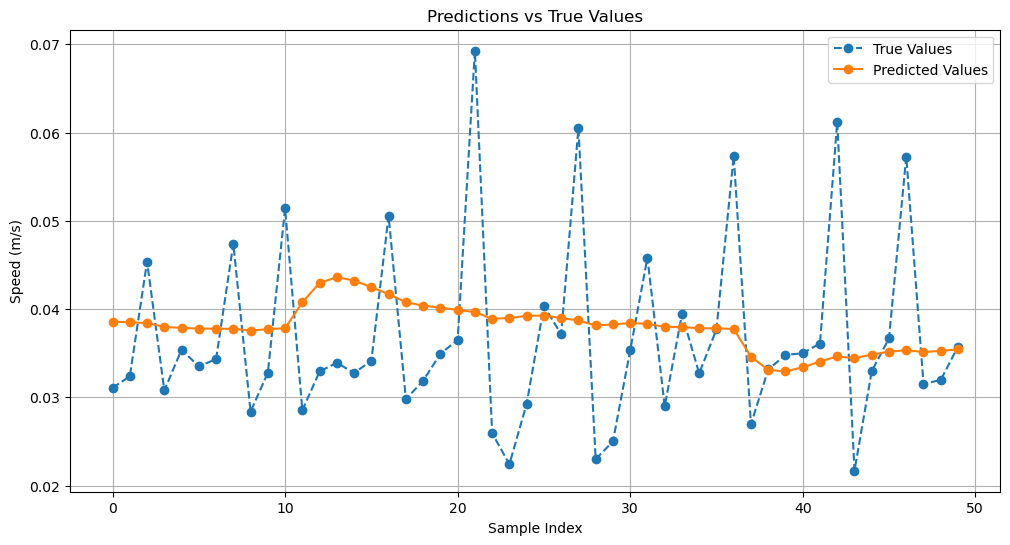

In [58]:
import matplotlib.pyplot as plt

# Use y_test as the true values
y_true = y_test

plt.figure(figsize=(12, 6))
plt.plot(y_true[:50], 'o--', label='True Values')         # Blå prickar och streck
plt.plot(predictions[:50], 'o-', label='Predicted Values')     # Orange linje
plt.title('Predictions vs True Values')
plt.xlabel('Sample Index')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.grid(True)
plt.show()

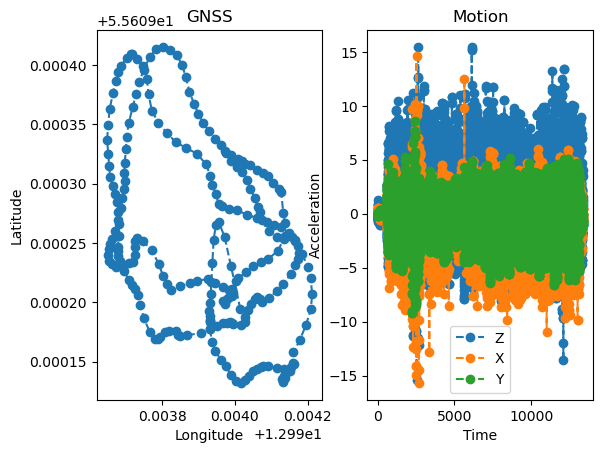

In [52]:
# Example of how to plot position data
fig = plt.figure()
ax = fig.add_subplot(121)
ax.plot(selection[0].positions['longitude'], selection[0].positions['latitude'],'o--')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('GNSS')

ax = fig.add_subplot(122)
ax.plot(selection[0].motion['accelZ'],'o--', label='Z')
ax.plot(selection[0].motion['accelX'],'o--', label='X')
ax.plot(selection[0].motion['accelY'],'o--', label='Y')
ax.set_xlabel('Time')
ax.set_ylabel('Acceleration')
ax.legend()
ax.set_title('Motion')
plt.show()
